
## Biomedical Dynamic Systems

* NIO
* To get the low-tumor group, change only one line:
* loss = torch.mean(final_tumor)


In [1]:


import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd


In [2]:


dt    = 0.01
iters = 1000

device = "cuda" if torch.cuda.is_available() else "cpu"


In [3]:



# -----------------------------------
# Tumor-Immune-Cytokine Model
# -----------------------------------

class TumorImmuneStep(nn.Module):

    def __init__(self, dt=0.01):

        super().__init__()

        # tumor growth
        self.a = 0.50
        self.b = 0.01

        # immune suppression
        self.c = 0.02

        # immune dynamics
        self.d = 0.01
        self.e = 0.10
        self.f = 0.05

        # cytokine dynamics
        self.g = 0.05
        self.h = 0.10

        self.dt = dt

    def forward(self, x):

        T = x[:,0]
        I = x[:,1]
        C = x[:,2]

        dT = self.a*T*(1.0 - self.b*T) - self.c*T*I

        dI = self.d*T*I - self.e*I + self.f*C

        dC = self.g*T - self.h*C

        T = T + self.dt*dT
        I = I + self.dt*dI
        C = C + self.dt*dC

        T = torch.clamp(T, min=0.0)
        I = torch.clamp(I, min=0.0)
        C = torch.clamp(C, min=0.0)

        return torch.stack([T,I,C], dim=1)



In [4]:


model = TumorImmuneStep(dt=dt).to(device)


In [5]:


# -----------------------------------
# search space
# -----------------------------------

low = torch.tensor(
    [1.0, 1.0, 1.0],
    device=device
)

high = torch.tensor(
    [100.0, 100.0, 100.0],
    device=device
)


In [6]:


N = 1000

T_list = [300,500,900,1300]

avg_tumor_list = []

optimized_rows = []


In [7]:



# -----------------------------------
# MAIN LOOP
# -----------------------------------

for Time_steps in T_list:

    print("\nRunning NIO for T =", Time_steps)

    z_init = torch.randn(
        N,
        3,
        device=device,
        requires_grad=True
    )

    optimizer = optim.Adam(
        [z_init],
        lr=0.05
    )

    # -----------------------------------
    # NIO
    # -----------------------------------

    for i in range(iters):

        x0 = low + (high-low)*torch.sigmoid(z_init)

        x = x0

        for t in range(Time_steps):

            x = model(x)

        final_tumor = x[:,0]

        # -----------------------------------
        # MIN TUMOR
        # -----------------------------------

    
        
        loss = torch.mean(final_tumor)
        

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if i % 100 == 0:

            print(
                "iter",
                i,
                "loss",
                loss.item()
            )

    # -----------------------------------
    # SAVE RESULTS
    # -----------------------------------

    with torch.no_grad():

        x0 = low + (high-low)*torch.sigmoid(z_init)

        x0_cpu = x0.cpu().numpy()

        for point_id in range(N):

            optimized_rows.append({

                "Time_steps": Time_steps,

                "point_id": point_id,

                "T0": x0_cpu[point_id,0],

                "I0": x0_cpu[point_id,1],

                "C0": x0_cpu[point_id,2]

            })

        x = x0

        for t in range(Time_steps):

            x = model(x)

        final_tumor = x[:,0]

        avg_tumor = final_tumor.mean().item()

        avg_tumor_list.append(
            avg_tumor
        )

        print(
            "T =",
            Time_steps,
            "avg final tumor =",
            avg_tumor
        )




Running NIO for T = 300
iter 0 loss 5.0936784744262695
iter 100 loss 0.24446484446525574
iter 200 loss 0.15931054949760437
iter 300 loss 0.1316026747226715
iter 400 loss 0.11797720938920975
iter 500 loss 0.10992854088544846
iter 600 loss 0.10464378446340561
iter 700 loss 0.1009254902601242
iter 800 loss 0.09817841649055481
iter 900 loss 0.09607377648353577
T = 300 avg final tumor = 0.09441526979207993

Running NIO for T = 500
iter 0 loss 1.407112956047058
iter 100 loss 0.026540255174040794
iter 200 loss 0.013812096789479256
iter 300 loss 0.009695745073258877
iter 400 loss 0.007688221056014299
iter 500 loss 0.006504965014755726
iter 600 loss 0.005726207047700882
iter 700 loss 0.005175262223929167
iter 800 loss 0.0047651068307459354
iter 900 loss 0.004447986371815205
T = 500 avg final tumor = 0.004195527173578739

Running NIO for T = 900
iter 0 loss 0.3416443467140198
iter 100 loss 0.002159572672098875
iter 200 loss 0.0009406650788150728
iter 300 loss 0.0005661803297698498
iter 400 loss

In [8]:

# -----------------------------------
# SAVE CSV
# -----------------------------------

df = pd.DataFrame(
    optimized_rows
)

df.to_csv(
    "nio_tumor_min.csv",
    index=False
)

print(
    "saved nio_tumor_min.csv"
)



saved nio_tumor_min.csv


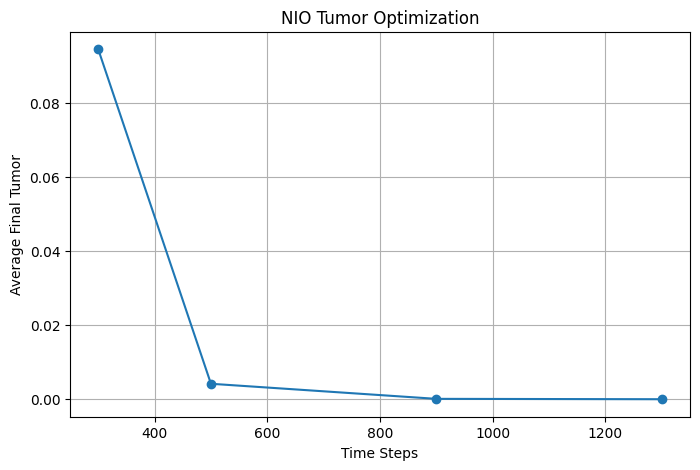

In [9]:


# -----------------------------------
# PLOT
# -----------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    T_list,
    avg_tumor_list,
    marker="o"
)

plt.xlabel("Time Steps")

plt.ylabel("Average Final Tumor")

plt.title(
    "NIO Tumor Optimization"
)

plt.grid(True)

plt.show()
